In [1]:
import numpy as np
import matplotlib.pyplot as plt
import traci
import os
from tqdm import tqdm

In [2]:
SUMO_BINARY = "sumo"
SUMO_CONFIG = os.path.join("..", "sumo_network", "data", "simulation.sumocfg")
SIM_END = 4200
CONTROL_STEP = 15

FLOW_WINDOW = 300  # seconds

In [3]:
main_dets = [f'det_main_arr_{i}' for i in range(4)]
ramp_dets = [f'det_ramp_arr_{i}' for i in range(2)]

times = []

main_counts = []
ramp_counts = []

In [4]:
MAIN_T = [0, 600, 600.1, 3300, 3301, 4200]
MAIN_VEH = [7400, 7400, 7900, 7900, 4000, 4000]

RAMP_T = [0, 600, 600.1, 3300, 3600, 4200]
RAMP_VEH = [600, 1000, 1300, 1300, 500, 500]

def get_mainline_flow(t):
    return np.interp(t, MAIN_T, MAIN_VEH)

def get_ramp_flow(t):
    return np.interp(t, RAMP_T, RAMP_VEH)

def insertVehicles():
    t = traci.simulation.getTime()

    V_main = get_mainline_flow(t)
    p_main = V_main / (3600 * 4)

    for lane in range(4):
        if np.random.random() < p_main:
            traci.vehicle.add(f"main_{t}_{lane}", "route_main", typeID="car_main",
                departLane="best", departPos="free", departSpeed="random")

    # Process Ramp
    V_ramp = get_ramp_flow(t)
    p_ramp = V_ramp / (3600 * 2)

    for lane in range(2):
        if np.random.random() < p_ramp:
            traci.vehicle.add(f"ramp_{t}_{lane}", "route_ramp", typeID="car_ramp",
                departLane="best", departPos="free", departSpeed="random")


In [5]:
traci.start([SUMO_BINARY, "-c", SUMO_CONFIG, "--no-step-log", "true", "--no-warnings"])

for i in tqdm(range(SIM_END)):
    main_counts.append(np.sum([traci.inductionloop.getLastStepVehicleNumber(d) for d in main_dets]))
    ramp_counts.append(np.sum([traci.inductionloop.getLastStepVehicleNumber(d) for d in ramp_dets]))

    times.append(i)
    insertVehicles()

    traci.simulationStep()

traci.close()

 Retrying in 1 seconds


100%|██████████| 4200/4200 [00:11<00:00, 372.84it/s]


In [6]:
def getFlow(counts):
    counts = np.asarray(counts, dtype=float)
    counts_cumsum = np.cumsum(counts)

    flow = np.zeros(len(counts))
    half = FLOW_WINDOW // 2

    for i in range(len(counts)):
        s = max(0, i - half)
        e = min(len(counts)-1, i + half + 1)
        flow[i] = (counts_cumsum[e] - counts_cumsum[s]) / (e - s) * 3600

    return flow

ramp_flow = getFlow(ramp_counts)
main_flow = getFlow(main_counts)

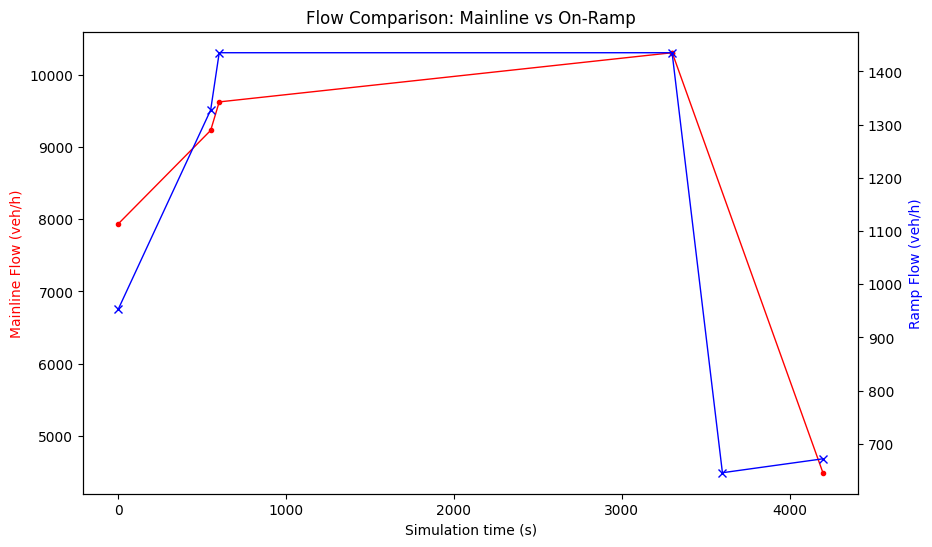

In [14]:
main_times_to_plot = np.asarray([0, 550, 601, 3300, 3301, 4199])
ramp_times_to_plot = np.asarray([0, 550, 601, 3300, 3600, 4199])

x_main = np.asarray(times)[main_times_to_plot]
y_main = main_flow[main_times_to_plot]

x_ramp = np.asarray(times)[ramp_times_to_plot]
y_ramp = ramp_flow[ramp_times_to_plot]

# Create the first plot (Mainline)
fig, ax1 = plt.subplots(figsize=(10, 6))

# Mainline Plot on Left Axis
ax1.plot(x_main, y_main, color="r", marker=".", linewidth=1, label="Mainline")
ax1.set_xlabel("Simulation time (s)")
ax1.set_ylabel("Mainline Flow (veh/h)", color="r")
ax1.tick_params(axis='y')

# Create the second y-axis sharing the same x-axis
ax2 = ax1.twinx()

# Ramp Plot on Right Axis
ax2.plot(x_ramp, y_ramp, color="b", marker="x", linewidth=1, label="Ramp")
ax2.set_ylabel("Ramp Flow (veh/h)", color="b")
ax2.tick_params(axis='y')

# Move the ramp axis label/ticks to the right (default for twinx)
ax2.yaxis.tick_right()
ax2.yaxis.set_label_position("right")

plt.title("Flow Comparison: Mainline vs On-Ramp")
plt.show()

In [8]:
# import numpy as np

# # Defined nodes from the plot
# main_t = [0, 600, 600.1, 3300, 3600, 4200]
# main_v = [7400, 7400, 7900, 7900, 4000, 4000]

# ramp_t = [0, 600, 600.1, 3300, 3600, 4200]
# ramp_v = [600, 1000, 1300, 1300, 500, 500]

# def get_mainline_flow(t):
#     return np.interp(t, main_t, main_v)

# def get_ramp_flow(t):
#     return np.interp(t, ramp_t, ramp_v)

In [9]:
# def insertVehicles():
#     t = traci.simulation.getTime()

#     V_main = get_mainline_flow(t)
#     p_main = V_main / (3600 * 4) # Assuming 4 mainline lanes

#     for lane in range(4):
#         if np.random.random() < p_main:
#             traci.vehicle.add(f"main_{t}_{lane}", "route_main", typeID="car_main")

#     # Process Ramp
#     V_ramp = get_ramp_flow(t)
#     p_ramp = V_ramp / (3600 * 2) # Assuming 2 ramp lanes

#     for lane in range(2):
#         if np.random.random() < p_ramp:
#             traci.vehicle.add(f"ramp_{t}_{lane}", "route_ramp", typeID="car_ramp")

In [10]:
# traci.start([SUMO_BINARY, "-c", SUMO_CONFIG, "--no-step-log", "true", "--no-warnings"])

# main_probs = []
# ramp_probs = []

# for step in range(SIM_END):

#     insertVehicles()

#     traci.simulationStep()

# traci.close()

In [11]:
# plt.plot(main_probs)